# Installation

In [36]:
from pycaret.utils import version
version()

'3.3.2'

# 1. Importing Dataset

In [37]:
# from pycaret.datasets import get_data
# data = get_data('juice')

In [38]:
import pandas as pd

data = pd.read_csv('https://docs.google.com/spreadsheets/d/1Ml6R5X3z86PWYCR6429RmlDeJquGstzow6mqbrdgVL8/export?gid=268077608&format=csv', encoding='UTF-8')
data = data.rename(columns={
  "Timestamp": "timestamp"
  , "เพศของผู้ตอบแบบสอบถาม": "sex"
  , "ช่วงอายุของผู้ตอบแบบสอบถาม": "age"
  , "อาชีพของผู้ตอบแบบสอบถาม": "job"
  , "ช่วงเงินเดือนของผู้ตอบแบบสอบถาม": "salary"
  , "ปัจจุบันท่านใช้สมาร์ทโฟนระบบปฎิบัติการใด": "current_os"
  , "ท่านใช้สมาร์ทโฟนในการทำอะไรมากที่สุด [เล่นเกม]": "usage_game"
  , "ท่านใช้สมาร์ทโฟนในการทำอะไรมากที่สุด [เล่นโซเชี่ยลมีเดีย]": "usage_social"
  , "ท่านใช้สมาร์ทโฟนในการทำอะไรมากที่สุด [ดูหนัง ฟังเพลง]": "usage_music"
  , "ท่านใช้สมาร์ทโฟนในการทำอะไรมากที่สุด [ถ่ายรูป ถ่ายวิดีโอ]": "usage_photo"
  , "หากท่านซื้อสมาร์ทโฟนเครื่องใหม่ จะใช้เลือกซื้อสมาร์ทโฟนแบรนด์ใด": "next_os"
  , "จากข้อที่แล้ว เนื่องจากสาเหตุใด": "reason"
})
# data = data[~data['next_os'].isin(['Oppo','Nokia'])]
data = data.drop(['next_os','reason'], axis=1)
data.head(3)

,timestamp,sex,age,job,salary,current_os,usage_game,usage_social,usage_music,usage_photo
0,8/17/2024 15:04:18,ชาย,21-25 ปี,ข้าราชการ,"20,001-30,000 บาท",IOS,บ่อยครั้ง,บ่อยที่สุด,บ่อยครั้ง,ปานกลาง
1,1/13/2024 15:02:46,หญิง,31-35 ปี,ข้าราชการ,"20,001-30,000 บาท",IOS,น้อยที่สุด,บ่อยครั้ง,บ่อยครั้ง,บ่อยครั้ง
2,1/13/2024 15:03:52,ชาย,26-30 ปี,ข้าราชการ,"20,001-30,000 บาท",Android,ปานกลาง,ค่อนข้างน้อย,ปานกลาง,น้อยที่สุด


# 2. Setting up Environment

In [39]:
from pycaret.classification import *
clf1 = setup(data, target = 'current_os', session_id=234, ignore_features=['timestamp'])

,Description,Value
0,Session id,234
1,Target,current_os
2,Target type,Binary
3,Target mapping,"Android: 0, IOS: 1"
4,Original data shape,"(69, 10)"
5,Transformed data shape,"(69, 36)"
6,Transformed train set shape,"(48, 36)"
7,Transformed test set shape,"(21, 36)"
8,Ignore features,1
9,Categorical features,8


# 3. Compare Models

In [40]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.8100,0.6042,0.8100,0.6980,0.7478,0.1667,0.1667,0.0150
et,Extra Trees Classifier,0.8100,0.6583,0.8100,0.6865,0.7371,0.1545,0.1612,0.0240
rf,Random Forest Classifier,0.7900,0.6750,0.7900,0.6245,0.6975,0.0000,0.0000,0.0230
dummy,Dummy Classifier,0.7900,0.5000,0.7900,0.6245,0.6975,0.0000,0.0000,0.0120
lr,Logistic Regression,0.7500,0.5667,0.7500,0.6138,0.6721,-0.0364,-0.0408,0.6790
gbc,Gradient Boosting Classifier,0.7350,0.5000,0.7350,0.6789,0.6921,0.0536,0.0658,0.0160
ridge,Ridge Classifier,0.7300,0.5083,0.7300,0.6652,0.6783,0.0331,0.0521,0.0120
qda,Quadratic Discriminant Analysis,0.7100,0.4917,0.7100,0.6578,0.6743,0.0958,0.0729,0.0120
lda,Linear Discriminant Analysis,0.6900,0.5000,0.6900,0.6545,0.6529,-0.0032,0.0112,0.0120
dt,Decision Tree Classifier,0.6500,0.5250,0.6500,0.6755,0.6217,0.0085,0.0362,0.0140


KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=-1, n_neighbors=5, p=2,
                     weights='uniform')

# 4. Create Model

In [41]:
lr = create_model('lr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.7500,0.8000,0.6400,0.7111,0.0000,0.0000
1,0.8000,0.7500,0.8000,0.6400,0.7111,0.0000,0.0000
2,0.8000,0.0000,0.8000,0.6400,0.7111,0.0000,0.0000
3,0.8000,0.2500,0.8000,0.6400,0.7111,0.0000,0.0000
4,0.4000,0.2500,0.4000,0.5333,0.4571,-0.3636,-0.4082
5,0.8000,1.0000,0.8000,0.6400,0.7111,0.0000,0.0000
6,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
7,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
8,0.7500,1.0000,0.7500,0.5625,0.6429,0.0000,0.0000


In [42]:
dt = create_model('dt')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
1,0.6000,0.3750,0.6000,0.6000,0.6000,-0.2500,-0.2500
2,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
3,0.4000,0.2500,0.4000,0.5333,0.4571,-0.3636,-0.4082
4,0.6000,0.7500,0.6000,0.8667,0.6333,0.2857,0.4082
5,0.4000,0.6250,0.4000,0.8500,0.4000,0.1176,0.2500
6,0.8000,0.8750,0.8000,0.9000,0.8190,0.5455,0.6124
7,0.6000,0.3750,0.6000,0.6000,0.6000,-0.2500,-0.2500
8,0.7500,0.5000,0.7500,0.5625,0.6429,0.0000,0.0000


# 5. Tune Model

In [43]:
tuned_dt = tune_model(dt)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
1,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
2,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
3,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
4,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
5,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
6,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
7,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
8,0.7500,0.5000,0.7500,0.5625,0.6429,0.0000,0.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [44]:
tuned_lr = tune_model(lr, optimize = 'AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.7500,0.8000,0.6400,0.7111,0.0000,0.0000
1,0.8000,0.7500,0.8000,0.6400,0.7111,0.0000,0.0000
2,0.8000,0.0000,0.8000,0.6400,0.7111,0.0000,0.0000
3,0.4000,0.2500,0.4000,0.5333,0.4571,-0.3636,-0.4082
4,0.6000,0.5000,0.6000,0.8667,0.6333,0.2857,0.4082
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
7,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
8,0.7500,1.0000,0.7500,0.5625,0.6429,0.0000,0.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [45]:
print(tuned_lr)

LogisticRegression(C=2.804, class_weight={}, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=234, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


# 6. Ensemble Model

In [46]:
bagged_dt = ensemble_model(dt)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.1250,0.8000,0.6400,0.7111,0.0000,0.0000
1,0.8000,0.0000,0.8000,0.6400,0.7111,0.0000,0.0000
2,0.8000,0.1250,0.8000,0.6400,0.7111,0.0000,0.0000
3,0.4000,0.1250,0.4000,0.5333,0.4571,-0.3636,-0.4082
4,0.6000,0.6250,0.6000,0.8667,0.6333,0.2857,0.4082
5,0.8000,1.0000,0.8000,0.9000,0.8190,0.5455,0.6124
6,0.6000,0.3750,0.6000,0.6000,0.6000,-0.2500,-0.2500
7,0.8000,0.7500,0.8000,0.9000,0.8190,0.5455,0.6124
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [47]:
boosted_dt = ensemble_model(dt, method = 'Boosting')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
1,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
2,0.6000,0.3750,0.6000,0.6000,0.6000,-0.2500,-0.2500
3,0.6000,0.3750,0.6000,0.6000,0.6000,-0.2500,-0.2500
4,0.8000,0.8750,0.8000,0.9000,0.8190,0.5455,0.6124
5,0.6000,0.7500,0.6000,0.8667,0.6333,0.2857,0.4082
6,0.8000,0.8750,0.8000,0.9000,0.8190,0.5455,0.6124
7,0.6000,0.3750,0.6000,0.6000,0.6000,-0.2500,-0.2500
8,0.7500,0.5000,0.7500,0.5625,0.6429,0.0000,0.0000


# 7. Blend Models

In [48]:
#lr = create_model('lr', verbose=False)
lda = create_model('lda', verbose=False)
gbc = create_model('gbc', verbose=False)

In [49]:
blender = blend_models(estimator_list=[tuned_lr , lda, gbc], method = 'soft')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.7500,0.8000,0.6400,0.7111,0.0000,0.0000
1,0.6000,0.5000,0.6000,0.6000,0.6000,-0.2500,-0.2500
2,0.8000,0.0000,0.8000,0.6400,0.7111,0.0000,0.0000
3,0.6000,0.2500,0.6000,0.6000,0.6000,-0.2500,-0.2500
4,0.6000,0.7500,0.6000,0.8667,0.6333,0.2857,0.4082
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,0.6000,0.2500,0.6000,0.6000,0.6000,-0.2500,-0.2500
7,0.8000,0.7500,0.8000,0.6400,0.7111,0.0000,0.0000
8,0.7500,1.0000,0.7500,0.5625,0.6429,0.0000,0.0000


In [50]:
blender.estimators_

[LogisticRegression(C=2.804, class_weight={}, dual=False, fit_intercept=True,
                    intercept_scaling=1, l1_ratio=None, max_iter=1000,
                    multi_class='auto', n_jobs=None, penalty='l2',
                    random_state=234, solver='lbfgs', tol=0.0001, verbose=0,
                    warm_start=False),
 LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                            priors=None, shrinkage=None, solver='svd',
                            store_covariance=False, tol=0.0001),
 GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                            learning_rate=0.1, loss='log_loss', max_depth=3,
                            max_features=None, max_leaf_nodes=None,
                            min_impurity_decrease=0.0, min_samples_leaf=1,
                            min_samples_split=2, min_weight_fraction_leaf=0.0,
                            n_estimators=100, n_iter_no_change=None,
          

# 8. Analyze Model

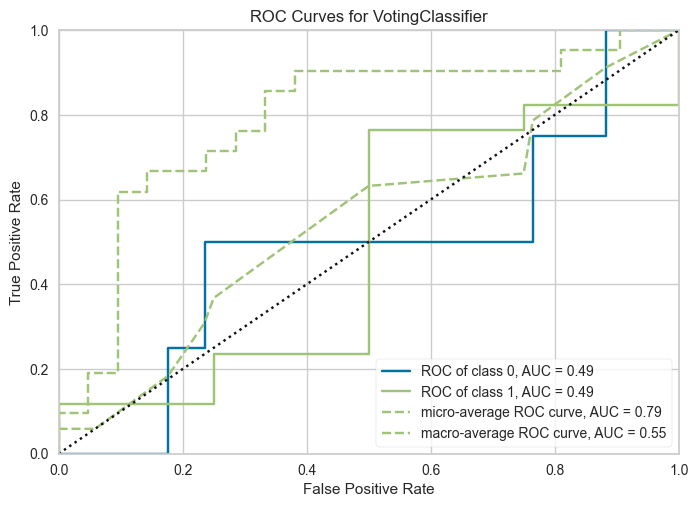

In [51]:
plot_model(blender)

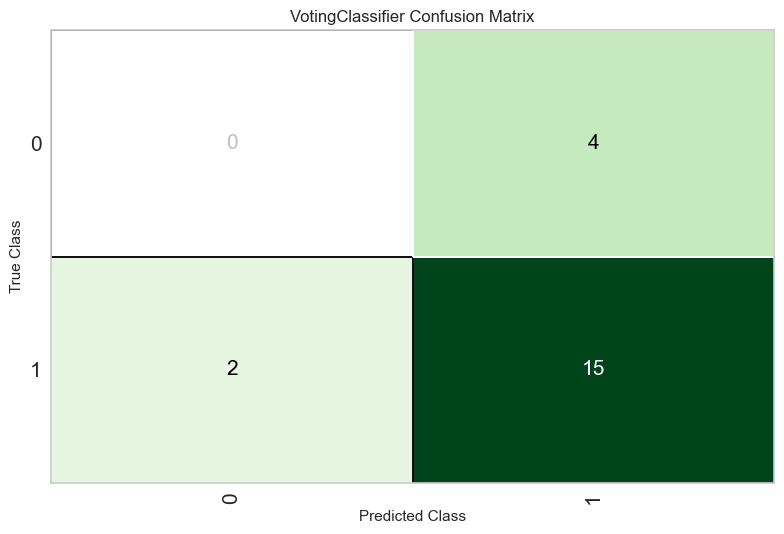

In [52]:
plot_model(blender, plot = 'confusion_matrix')

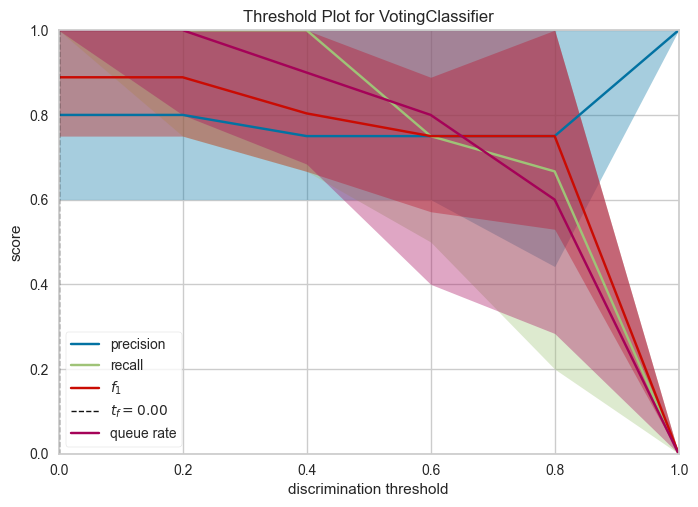

In [53]:
plot_model(blender, plot = 'threshold')

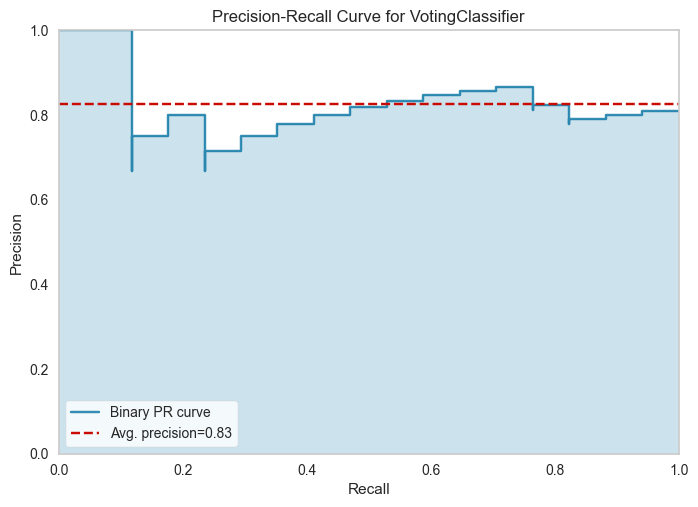

In [54]:
plot_model(blender, plot = 'pr')

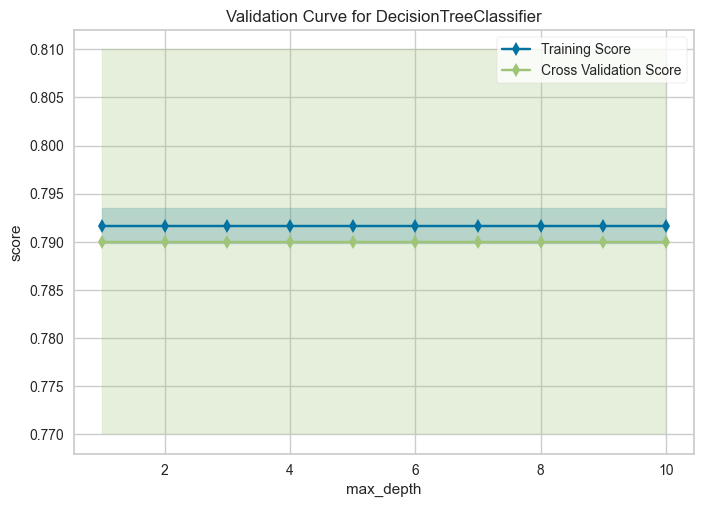

In [55]:
plot_model(tuned_dt, plot = 'vc')

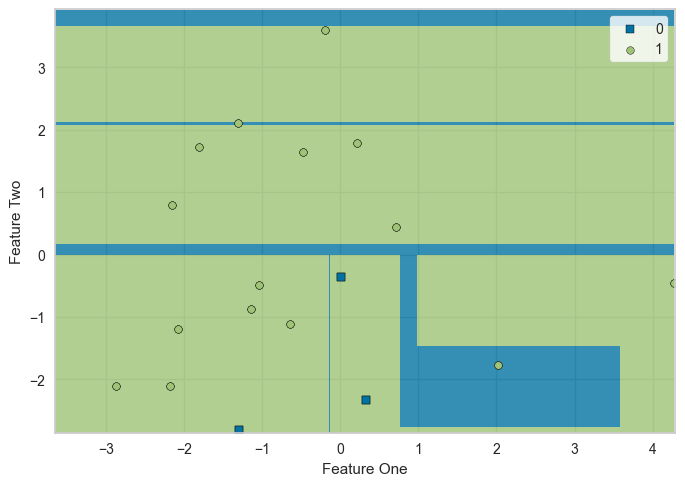

In [56]:
plot_model(dt, plot = 'boundary')

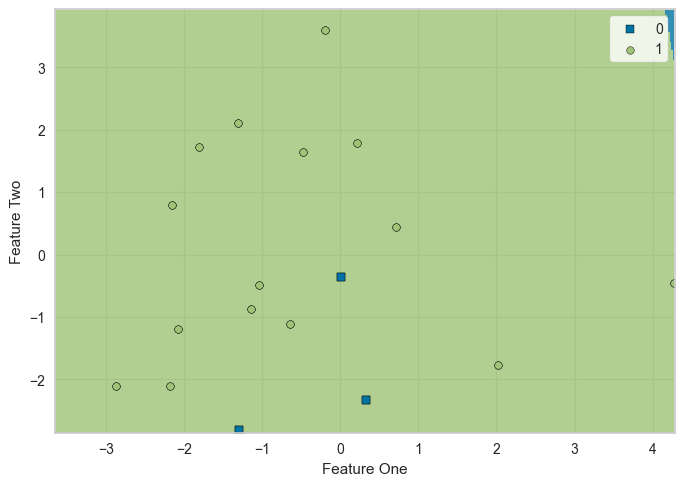

In [57]:
plot_model(tuned_lr, plot = 'boundary')

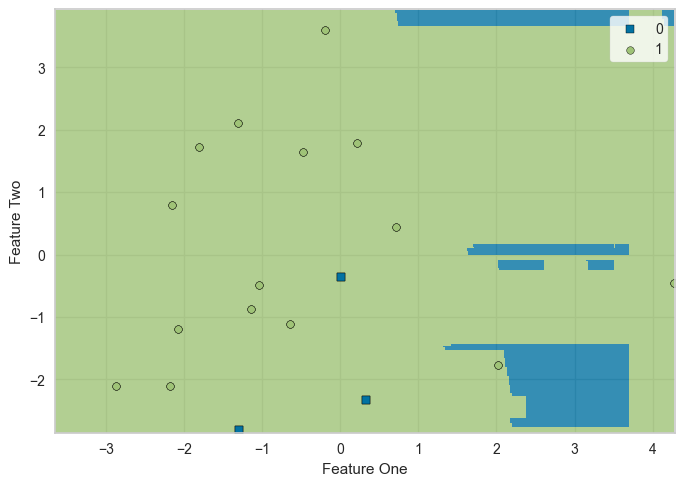

In [58]:
plot_model(blender, plot = 'boundary')

In [59]:
evaluate_model(tuned_lr)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

# 9. Interpret Model

In [61]:
# xgboost = clf1.create_model('xgboost')
xgboost = clf1.create_model('gbc')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.0000,0.8000,0.6400,0.7111,0.0000,0.0000
1,0.6000,0.2500,0.6000,0.6000,0.6000,-0.2500,-0.2500
2,0.8000,0.0000,0.8000,0.6400,0.7111,0.0000,0.0000
3,0.6000,0.0000,0.6000,0.6000,0.6000,-0.2500,-0.2500
4,0.6000,1.0000,0.6000,0.8667,0.6333,0.2857,0.4082
5,0.6000,0.7500,0.6000,0.6000,0.6000,-0.2500,-0.2500
6,0.8000,0.2500,0.8000,0.6400,0.7111,0.0000,0.0000
7,0.8000,0.7500,0.8000,0.6400,0.7111,0.0000,0.0000
8,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [62]:
tuned_xgboost = tune_model(xgboost)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.7500,0.8000,0.6400,0.7111,0.0000,0.0000
1,0.8000,0.7500,0.8000,0.6400,0.7111,0.0000,0.0000
2,0.8000,0.0000,0.8000,0.6400,0.7111,0.0000,0.0000
3,0.8000,0.2500,0.8000,0.6400,0.7111,0.0000,0.0000
4,0.8000,0.0000,0.8000,0.6400,0.7111,0.0000,0.0000
5,0.8000,0.7500,0.8000,0.6400,0.7111,0.0000,0.0000
6,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
7,0.8000,0.5000,0.8000,0.6400,0.7111,0.0000,0.0000
8,0.7500,1.0000,0.7500,0.5625,0.6429,0.0000,0.0000


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [63]:
interpret_model(tuned_xgboost)

TypeError: This function only supports tree based models for binary classification: dt, et, rf, lightgbm.

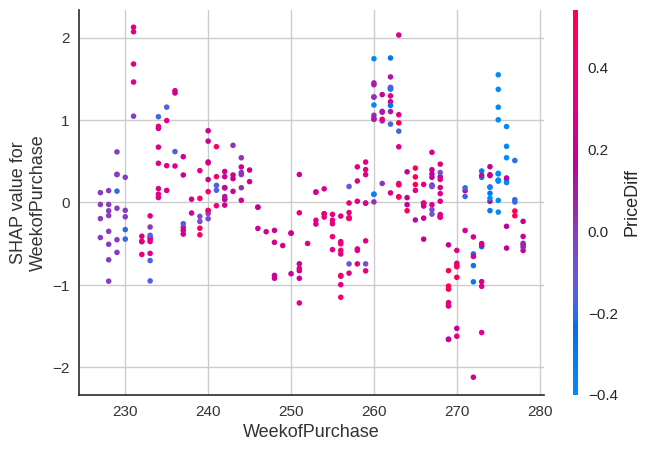

In [ ]:
interpret_model(tuned_xgboost, plot = 'correlation')

In [ ]:
predict_model(tuned_xgboost)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.7850,0.8518,0.7850,0.7847,0.7849,0.5473,0.5473


,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE,Purchase,prediction_label,prediction_score
413,235,3,1.79,2.09,0.0,0.00,0,0,0.181687,2.09,1.79,0.30,No,0.000000,0.0,0.30,3,MM,MM,0.7728
921,269,2,1.86,2.18,0.0,0.00,0,0,0.616000,2.18,1.86,0.32,No,0.000000,0.0,0.32,2,CH,CH,0.9971
468,272,7,1.86,2.13,0.0,0.00,0,0,0.890948,2.13,1.86,0.27,Yes,0.000000,0.0,0.27,0,CH,CH,0.9994
1044,241,1,1.86,1.99,0.0,0.30,0,1,0.777178,1.69,1.86,-0.17,No,0.150754,0.0,0.13,1,CH,CH,0.7885
211,259,7,1.86,2.18,0.0,0.00,0,0,0.938797,2.18,1.86,0.32,Yes,0.000000,0.0,0.32,0,CH,CH,0.9997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
701,248,3,1.99,2.23,0.0,0.00,0,0,0.002951,2.23,1.99,0.24,No,0.000000,0.0,0.24,3,MM,MM,0.9955
287,261,3,1.99,2.09,0.0,0.00,0,0,0.001209,2.09,1.99,0.10,No,0.000000,0.0,0.10,3,MM,MM,0.9986
421,261,3,1.99,2.09,0.0,0.00,0,0,0.030482,2.09,1.99,0.10,No,0.000000,0.0,0.10,3,MM,MM,0.9978
854,240,7,1.86,2.09,0.0,0.00,0,0,0.916114,2.09,1.86,0.23,Yes,0.000000,0.0,0.23,0,CH,CH,0.9990


In [65]:
interpret_model(tuned_xgboost, plot = 'reason', observation=1)

TypeError: This function only supports tree based models for binary classification: dt, et, rf, lightgbm.

In [ ]:
interpret_model(tuned_xgboost, plot = 'reason')

# Learning Resources:

- PyCaret Classification Module : https://www.pycaret.org/classification
- Binary Classification Tutorial (Level Beginner) : https://pycaret.org/clf101/
- Binary Classification Tutorial (Level Intermediate) : https://pycaret.org/clf102/
- Kaggle Titanic Predictions (Video Tutorial) : https://www.youtube.com/watch?v=nqMM6rngNCA